In [ ]:
print("Hello Bro 😎")

Hello Bro 😎


In [ ]:
import pandas as pd

df = pd.read_csv("customer_support_tickets(2).csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'customer_support_tickets(2).csv'

In [ ]:
import os

print(os.listdir())

['.config', 'customer_support_tickets.csv (2).zip', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("customer_support_tickets.csv")

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [ ]:
df.shape

(8469, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [ ]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Product Purchased,0
Date of Purchase,0
Ticket Type,0
Ticket Subject,0
Ticket Description,0


In [ ]:
df["Ticket Type"].value_counts()

,count
Ticket Type,
Refund request,1752
Technical issue,1747
Cancellation request,1695
Product inquiry,1641
Billing inquiry,1634


In [ ]:
df["Ticket Priority"].value_counts()

,count
Ticket Priority,
Medium,2192
Critical,2129
High,2085
Low,2063


In [ ]:
df["Ticket Status"].value_counts()

,count
Ticket Status,
Pending Customer Response,2881
Open,2819
Closed,2769


In [ ]:
 df_ml = df[["Ticket Description", "Ticket Type", "Ticket Priority"]]

df_ml.head()

,Ticket Description,Ticket Type,Ticket Priority
0,I'm having an issue with the {product_purchase...,Technical issue,Critical
1,I'm having an issue with the {product_purchase...,Technical issue,Critical
2,I'm facing a problem with my {product_purchase...,Technical issue,Low
3,I'm having an issue with the {product_purchase...,Billing inquiry,Low
4,I'm having an issue with the {product_purchase...,Billing inquiry,Low


In [ ]:
df_ml.isnull().sum()


,0
Ticket Description,0
Ticket Type,0
Ticket Priority,0


In [ ]:
df_ml.head()

,Ticket Description,Ticket Type,Ticket Priority
0,I'm having an issue with the {product_purchase...,Technical issue,Critical
1,I'm having an issue with the {product_purchase...,Technical issue,Critical
2,I'm facing a problem with my {product_purchase...,Technical issue,Low
3,I'm having an issue with the {product_purchase...,Billing inquiry,Low
4,I'm having an issue with the {product_purchase...,Billing inquiry,Low


In [ ]:
import re
import string
import nltk

from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [ ]:
df_ml["Cleaned_Text"] = df_ml["Ticket Description"].apply(clean_text)

/tmp/ipykernel_872/960943573.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml["Cleaned_Text"] = df_ml["Ticket Description"].apply(clean_text)


In [ ]:
df_ml[["Ticket Description", "Cleaned_Text"]].head()

,Ticket Description,Cleaned_Text
0,I'm having an issue with the {product_purchase...,im issue productpurchased please assist billin...
1,I'm having an issue with the {product_purchase...,im issue productpurchased please assist need c...
2,I'm facing a problem with my {product_purchase...,im facing problem productpurchased productpurc...
3,I'm having an issue with the {product_purchase...,im issue productpurchased please assist proble...
4,I'm having an issue with the {product_purchase...,im issue productpurchased please assist note s...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

In [ ]:
X = tfidf.fit_transform(df_ml["Cleaned_Text"])

In [ ]:
y = df_ml["Ticket Type"]

In [ ]:
print(X.shape)
print(y.shape)

(8469, 5000)
(8469,)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (6775, 5000)
Testing Data  : (1694, 5000)


In [ ]:
from sklearn.naive_bayes import MultinomialNB

In [ ]:
model = MultinomialNB()

In [ ]:
model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.1859504132231405


In [ ]:
print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

     Billing inquiry       0.14      0.05      0.07       357
Cancellation request       0.17      0.15      0.16       327
     Product inquiry       0.16      0.14      0.15       316
      Refund request       0.20      0.30      0.24       345
     Technical issue       0.21      0.29      0.24       349

            accuracy                           0.19      1694
           macro avg       0.18      0.19      0.17      1694
        weighted avg       0.18      0.19      0.17      1694



In [ ]:
df_ml["Combined_Text"] = (
    df["Ticket Subject"] + " " + df["Ticket Description"]
)

/tmp/ipykernel_872/1438859456.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml["Combined_Text"] = (


In [ ]:
df_ml["Cleaned_Text"] = df_ml["Combined_Text"].apply(clean_text)

/tmp/ipykernel_872/925017973.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml["Cleaned_Text"] = df_ml["Combined_Text"].apply(clean_text)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(df_ml["Cleaned_Text"])

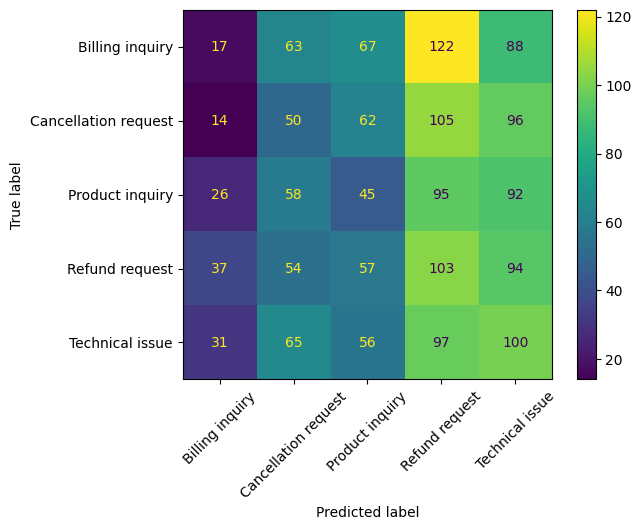

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=45)
plt.show()

In [ ]:
import joblib

joblib.dump(model, "ticket_classifier.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("TF-IDF Saved Successfully")

TF-IDF Saved Successfully


In [ ]:
new_ticket = ["My laptop is not turning on and I need immediate help"]

new_ticket_clean = [clean_text(new_ticket[0])]

new_vector = tfidf.transform(new_ticket_clean)

prediction = model.predict(new_vector)

print("Predicted Ticket Type:", prediction[0])

ValueError: X has 10000 features, but MultinomialNB is expecting 5000 features as input.

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df_ml["Cleaned_Text"])

y = df_ml["Ticket Type"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.1894923258559622
                      precision    recall  f1-score   support

     Billing inquiry       0.14      0.04      0.07       357
Cancellation request       0.17      0.16      0.16       327
     Product inquiry       0.15      0.13      0.14       316
      Refund request       0.20      0.31      0.24       345
     Technical issue       0.22      0.31      0.26       349

            accuracy                           0.19      1694
           macro avg       0.18      0.19      0.17      1694
        weighted avg       0.18      0.19      0.17      1694



In [ ]:
new_ticket = ["My laptop is not turning on and I need immediate help"]

new_ticket_clean = [clean_text(new_ticket[0])]

new_vector = tfidf.transform(new_ticket_clean)

prediction = model.predict(new_vector)

print("Predicted Ticket Type:", prediction[0])

Predicted Ticket Type: Product inquiry


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.1894923258559622
                      precision    recall  f1-score   support

     Billing inquiry       0.14      0.04      0.07       357
Cancellation request       0.17      0.16      0.16       327
     Product inquiry       0.15      0.13      0.14       316
      Refund request       0.20      0.31      0.24       345
     Technical issue       0.22      0.31      0.26       349

            accuracy                           0.19      1694
           macro avg       0.18      0.19      0.17      1694
        weighted avg       0.18      0.19      0.17      1694



In [ ]:
new_ticket = ["My laptop is not turning on and I need immediate help"]

new_ticket_clean = [clean_text(new_ticket[0])]

new_vector = tfidf.transform(new_ticket_clean)

prediction = model.predict(new_vector)

print("Predicted Ticket Type:", prediction[0])

Predicted Ticket Type: Product inquiry


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.1894923258559622
                      precision    recall  f1-score   support

     Billing inquiry       0.14      0.04      0.07       357
Cancellation request       0.17      0.16      0.16       327
     Product inquiry       0.15      0.13      0.14       316
      Refund request       0.20      0.31      0.24       345
     Technical issue       0.22      0.31      0.26       349

            accuracy                           0.19      1694
           macro avg       0.18      0.19      0.17      1694
        weighted avg       0.18      0.19      0.17      1694



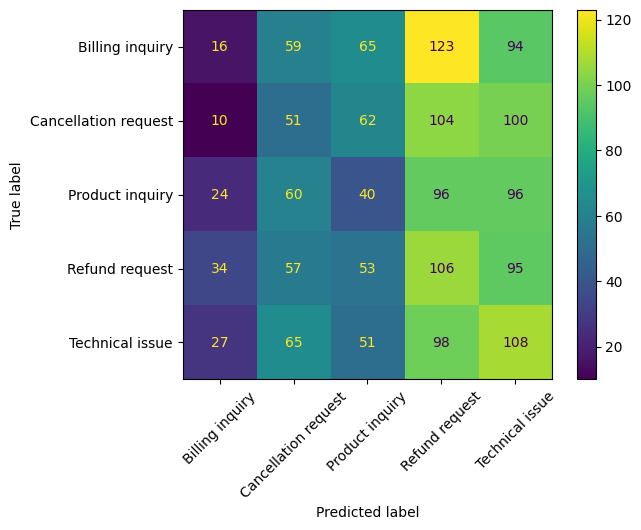

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.xticks(rotation=45)
plt.show()

In [ ]:
import joblib

joblib.dump(model, "ticket_classifier.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and TF-IDF saved successfully!")

Model and TF-IDF saved successfully!


In [ ]:
new_ticket = ["My laptop is not turning on and I need immediate help"]

new_ticket_clean = clean_text(new_ticket[0])

new_vector = tfidf.transform([new_ticket_clean])

prediction = model.predict(new_vector)

print("Predicted Ticket Type:", prediction[0])

Predicted Ticket Type: Product inquiry


In [ ]:
''